# Proyecto Integrador - Equipo 16
## Avance 5 — Optimización SARIMAX para Predicción de Sarampión en México

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598


---

Este notebook se enfoca en la **optimización exhaustiva del modelo SARIMAX** para la predicción de casos de sarampión en México, utilizando únicamente las **vacunas desplazadas** como variable exógena.

### Objetivos
1. Mostrar la estructura del dataframe final de modelación (`df_model`) y sus 30+ variables.
2. Preparar la serie de tiempo con la variable exógena de dosis de vacunación con desfase.
3. Realizar **selección de hiperparámetros** del SARIMAX (órdenes p, d, q y estacionalidad P, D, Q, s) mediante **validación temporal** (`TimeSeriesSplit`).
4. Evaluar con métricas: **RMSE**, **MAE** y **SMAPE**.
5. Graficar predicciones vs. valores observados para visualizar el ajuste y la capacidad de pronóstico.

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import product

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configuración global
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100


def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (0-100%)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100.0 * np.mean(np.abs(y_true - y_pred) / denom))


SPLIT_YEAR = 2019
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Carga de Datos

In [4]:
base_path = Path("../../..") / "data" / "processed"

# Dataset de Features (Ingeniería de características previa)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Dataset original con totales de dosis (Vacunas)
df_vacunas = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

print(f"Dataset df_fe: {df_fe.shape}")
print(f"Dataset df_vacunas: {df_vacunas.shape}")
print(f"\nColumnas df_fe:\n{list(df_fe.columns)}")

Dataset df_fe: (154, 31)
Dataset df_vacunas: (168, 5)

Columnas df_fe:
['fecha', 'anio', 'mes', 'casos_sarampion', 'casos_sarampion_log', 'casos_ytd_log', 'casos_rolling_mean_3m', 'dosis_lag_14m_log', 'dosis_lag_13m_log', 'casos_rolling_mean_6m_log', 'dosis_rolling_mean_3m_log', 'total_dosis_log', 'dosis_rolling_std_3m_log', 'casos_lag_13m_log', 'anio_normalizado', 'dosis_rolling_std_6m_log', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']


---
## 2. Integración de Vacunas con Desfase

Se integra la variable de dosis de vacunación con un **desplazamiento temporal** configurable, capturando el efecto retardado de la vacunación sobre la incidencia de sarampión. Esta será la **única variable exógena** utilizada en el modelo SARIMAX.

In [5]:
MESES_DESFASE = 3  # Configurable según análisis


def integrar_vacunas_con_desfase(df_principal, df_vac, desfase_meses=0):
    df_vac_lag = df_vac.copy()
    df_vac_lag["fecha_join"] = df_vac_lag["fecha"] + pd.DateOffset(
        months=desfase_meses
    )
    col_name = f"total_dosis_lag_{desfase_meses}m"
    df_vac_lag = df_vac_lag[["fecha_join", "total_dosis"]].rename(
        columns={"total_dosis": col_name}
    )
    df_res = pd.merge(
        df_principal, df_vac_lag, left_on="fecha", right_on="fecha_join", how="left"
    )
    df_res.drop(columns=["fecha_join"], inplace=True)
    df_res.dropna(subset=[col_name], inplace=True)
    return df_res.reset_index(drop=True)


df_model = integrar_vacunas_con_desfase(df_fe, df_vacunas, desfase_meses=MESES_DESFASE)

# Excluir columnas PCA y Factor Analysis (componentes estáticos no útiles para series de tiempo)
pca_fa_cols = [c for c in df_model.columns if "pca" in c.lower() or "factor" in c.lower() or c.startswith("FA_")]
df_model.drop(columns=pca_fa_cols, inplace=True)
print(f"Columnas PCA/FA eliminadas: {pca_fa_cols}")

print(f"Dataset de modelación (df_model): {df_model.shape}")
print(
    f"Período: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}"
)

Columnas PCA/FA eliminadas: ['PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']
Dataset de modelación (df_model): (154, 17)
Período: 2011-03-01 → 2023-12-01


---
## 3. Estructura del DataFrame de Modelación (`df_model`)

Es importante mostrar la estructura del dataframe final resultado de la ingeniería de características. A continuación se listan todas las variables disponibles, sus tipos y estadísticas descriptivas.

In [6]:
print(f"Dimensiones de df_model: {df_model.shape[0]} filas × {df_model.shape[1]} columnas")
print(f"\n{'='*80}")
print(f"  LISTADO COMPLETO DE VARIABLES EN df_model ({df_model.shape[1]} columnas)")
print(f"{'='*80}")

for i, col in enumerate(df_model.columns, 1):
    dtype = df_model[col].dtype
    n_null = df_model[col].isnull().sum()
    print(f"  {i:>2}. {col:<35s} | Tipo: {str(dtype):<15s} | Nulos: {n_null}")

print(f"\n{'─'*80}")
print("Estadísticas descriptivas:")
display(df_model.describe().T)

Dimensiones de df_model: 154 filas × 17 columnas

  LISTADO COMPLETO DE VARIABLES EN df_model (17 columnas)
   1. fecha                               | Tipo: datetime64[ns]  | Nulos: 0
   2. anio                                | Tipo: int64           | Nulos: 0
   3. mes                                 | Tipo: int64           | Nulos: 0
   4. casos_sarampion                     | Tipo: int64           | Nulos: 0
   5. casos_sarampion_log                 | Tipo: float64         | Nulos: 0
   6. casos_ytd_log                       | Tipo: float64         | Nulos: 0
   7. casos_rolling_mean_3m               | Tipo: float64         | Nulos: 0
   8. dosis_lag_14m_log                   | Tipo: float64         | Nulos: 0
   9. dosis_lag_13m_log                   | Tipo: float64         | Nulos: 0
  10. casos_rolling_mean_6m_log           | Tipo: float64         | Nulos: 0
  11. dosis_rolling_mean_3m_log           | Tipo: float64         | Nulos: 0
  12. total_dosis_log                     | T

,count,mean,min,25%,50%,75%,max,std
fecha,154,2017-07-16 17:36:37.402597376,2011-03-01 00:00:00,2014-05-08 18:00:00,2017-07-16 12:00:00,2020-09-23 12:00:00,2023-12-01 00:00:00,NaN
anio,154.0,2017.077922,2011.0,2014.0,2017.0,2020.0,2023.0,3.71454
mes,154.0,6.564935,1.0,4.0,7.0,9.75,12.0,3.437443
casos_sarampion,154.0,1.655844,0.0,0.0,0.0,0.0,75.0,9.465714
casos_sarampion_log,154.0,0.183597,0.0,0.0,0.0,0.0,4.330733,0.713789
casos_ytd_log,154.0,0.478987,0.0,0.0,0.0,0.0,5.26269,1.298631
casos_rolling_mean_3m,154.0,1.655844,0.0,0.0,0.0,0.0,60.666667,7.554538
dosis_lag_14m_log,154.0,0.129751,-5.522493,-0.394271,-0.0,0.605729,4.898354,1.332477
dosis_lag_13m_log,154.0,0.123065,-5.488558,-0.397993,-0.0,0.602007,4.868255,1.328535
casos_rolling_mean_6m_log,154.0,0.348962,0.0,0.0,0.0,0.0,3.496508,0.822231


In [7]:
# Visualización de la distribución de las primeras variables clave
print("Primeras 5 filas de df_model:")
display(df_model.head())

print("\nÚltimas 5 filas de df_model:")
display(df_model.tail())

print(f"\nInfo del DataFrame:")
df_model.info()

Primeras 5 filas de df_model:


,fecha,anio,mes,casos_sarampion,casos_sarampion_log,casos_ytd_log,casos_rolling_mean_3m,dosis_lag_14m_log,dosis_lag_13m_log,casos_rolling_mean_6m_log,dosis_rolling_mean_3m_log,total_dosis_log,dosis_rolling_std_3m_log,casos_lag_13m_log,anio_normalizado,dosis_rolling_std_6m_log,total_dosis_lag_3m
0,2011-03-01,2011,3,0,0.0,0.0,0.0,-0.372922,-0.344933,1.427116,0.686942,1.238637,-0.111783,0.0,-1.0,-0.045729,391664
1,2011-04-01,2011,4,0,0.0,0.0,0.0,-0.347066,0.169054,1.427116,0.791342,0.651001,0.147760,0.0,-1.0,-0.293973,280892
2,2011-05-01,2011,5,0,0.0,0.0,0.0,0.170100,-0.040462,0.510826,0.864312,-0.309203,-0.044292,0.0,-1.0,-0.242333,365527
3,2011-06-01,2011,6,0,0.0,0.0,0.0,-0.040712,-0.435477,0.000000,0.508229,0.815245,0.482502,0.0,-1.0,0.032216,445427
4,2011-07-01,2011,7,0,0.0,0.0,0.0,-0.438169,1.138046,0.000000,0.292474,0.779094,0.192497,0.0,-1.0,0.002797,320114



Últimas 5 filas de df_model:


,fecha,anio,mes,casos_sarampion,casos_sarampion_log,casos_ytd_log,casos_rolling_mean_3m,dosis_lag_14m_log,dosis_lag_13m_log,casos_rolling_mean_6m_log,dosis_rolling_mean_3m_log,total_dosis_log,dosis_rolling_std_3m_log,casos_lag_13m_log,anio_normalizado,dosis_rolling_std_6m_log,total_dosis_lag_3m
149,2023-08-01,2023,8,0,0.0,0.0,0.0,-0.051626,-1.307940,0.0,0.457566,-0.275527,-0.871628,0.0,1.0,-0.762845,285941
150,2023-09-01,2023,9,0,0.0,0.0,0.0,-1.316026,-5.488558,0.0,0.232580,0.664685,0.088253,0.0,1.0,-0.355895,323897
151,2023-10-01,2023,10,0,0.0,0.0,0.0,-5.522493,-0.432028,0.0,0.229324,0.887351,0.084393,0.0,1.0,-0.347936,319238
152,2023-11-01,2023,11,0,0.0,0.0,0.0,-0.434699,-0.774066,0.0,0.341452,0.632052,0.225798,0.0,1.0,-0.246166,190148
153,2023-12-01,2023,12,0,0.0,0.0,0.0,-0.778852,-1.277513,0.0,0.619795,-0.054474,-0.683895,0.0,1.0,-0.248997,322586



Info del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      154 non-null    datetime64[ns]
 1   anio                       154 non-null    int64         
 2   mes                        154 non-null    int64         
 3   casos_sarampion            154 non-null    int64         
 4   casos_sarampion_log        154 non-null    float64       
 5   casos_ytd_log              154 non-null    float64       
 6   casos_rolling_mean_3m      154 non-null    float64       
 7   dosis_lag_14m_log          154 non-null    float64       
 8   dosis_lag_13m_log          154 non-null    float64       
 9   casos_rolling_mean_6m_log  154 non-null    float64       
 10  dosis_rolling_mean_3m_log  154 non-null    float64       
 11  total_dosis_log            154 non-null    float64

---
## 4. Partición Temporal Train / Test

Separación cronológica estricta: **Train ≤ 2018** y **Test ≥ 2019** para evitar *data leakage*.

In [8]:
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023

df_model = df_model[
    (df_model["anio"] >= TRAIN_START_YEAR) & (df_model["anio"] <= TEST_END_YEAR)
].copy()

print(
    f"Período filtrado: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}"
)
print(f"Registros totales: {len(df_model)}")

Período filtrado: 2011-03-01 → 2023-12-01
Registros totales: 154


---
## 5. Preparación de la Serie de Tiempo para SARIMAX

Para el modelo SARIMAX se utiliza:
- **Variable objetivo:** `casos_sarampion`
- **Variable exógena:** `total_dosis_lag_2m` (dosis de vacunación con 2 meses de desfase)

Se escala la exógena con estadísticos solo del conjunto de entrenamiento para evitar *data leakage*.

In [9]:
# Preparar serie y exógena
EXOG_COL = f"total_dosis_lag_{MESES_DESFASE}m"

ts_train_mask = df_model["anio"] <= TRAIN_END_YEAR
ts_test_mask = df_model["anio"] >= TEST_START_YEAR

y_train = df_model.loc[ts_train_mask, "casos_sarampion"].astype(float).reset_index(drop=True)
y_test = df_model.loc[ts_test_mask, "casos_sarampion"].astype(float).reset_index(drop=True)

exog_train = df_model.loc[ts_train_mask, [EXOG_COL]].reset_index(drop=True).astype(float)
exog_test = df_model.loc[ts_test_mask, [EXOG_COL]].reset_index(drop=True).astype(float)

dates_train = df_model.loc[ts_train_mask, "fecha"].reset_index(drop=True)
dates_test = df_model.loc[ts_test_mask, "fecha"].reset_index(drop=True)

# Escalado de la exógena (estadísticos solo del train)
exog_mean = exog_train.mean()
exog_std = exog_train.std().replace(0, 1.0)
exog_train_sc = (exog_train - exog_mean) / exog_std
exog_test_sc = (exog_test - exog_mean) / exog_std

print(f"Serie Train: {y_train.shape[0]} obs ({dates_train.min().date()} → {dates_train.max().date()})")
print(f"Serie Test:  {y_test.shape[0]} obs ({dates_test.min().date()} → {dates_test.max().date()})")
print(f"\nVariable exógena: {EXOG_COL}")
print(f"  Train — media: {exog_train[EXOG_COL].mean():.2f}, std: {exog_train[EXOG_COL].std():.2f}")
print(f"  Test  — media: {exog_test[EXOG_COL].mean():.2f}, std: {exog_test[EXOG_COL].std():.2f}")

Serie Train: 94 obs (2011-03-01 → 2018-12-01)
Serie Test:  60 obs (2019-01-01 → 2023-12-01)

Variable exógena: total_dosis_lag_3m
  Train — media: 318931.13, std: 379132.17
  Test  — media: 319859.45, std: 362495.05


---
## 6. Análisis Exploratorio de la Serie

Antes de ajustar el SARIMAX, es fundamental:
1. Visualizar la serie y la exógena.
2. Evaluar estacionariedad (tests ADF y KPSS).
3. Inspeccionar las funciones de autocorrelación (ACF/PACF) para guiar la selección de órdenes.

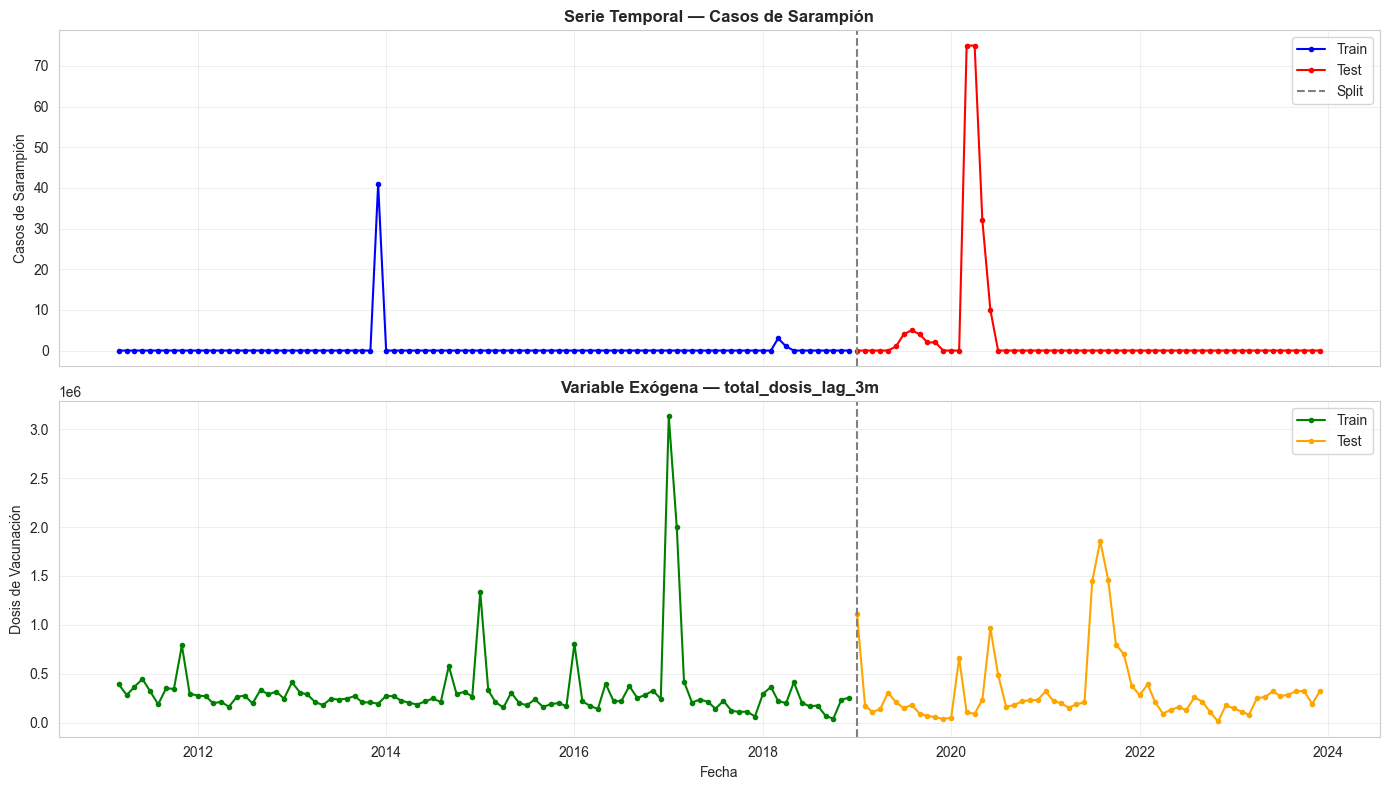

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Serie de casos
axes[0].plot(dates_train, y_train, "b-o", ms=3, lw=1.5, label="Train")
axes[0].plot(dates_test, y_test, "r-o", ms=3, lw=1.5, label="Test")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5, label="Split")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("Serie Temporal — Casos de Sarampión", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variable exógena (dosis con desfase)
exog_all = pd.concat(
    [exog_train[EXOG_COL], exog_test[EXOG_COL]], ignore_index=True
)
dates_all = pd.concat([dates_train, dates_test], ignore_index=True)

axes[1].plot(dates_train, exog_train[EXOG_COL], "g-o", ms=3, lw=1.5, label="Train")
axes[1].plot(dates_test, exog_test[EXOG_COL], "orange", marker="o", ms=3, lw=1.5, label="Test")
axes[1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5)
axes[1].set_ylabel("Dosis de Vacunación")
axes[1].set_xlabel("Fecha")
axes[1].set_title(f"Variable Exógena — {EXOG_COL}", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Tests de estacionariedad sobre la serie de entrenamiento
print("="*60)
print("  TESTS DE ESTACIONARIEDAD — Serie de Entrenamiento")
print("="*60)

# ADF Test
adf_result = adfuller(y_train, autolag="AIC")
print(f"\n▸ Augmented Dickey-Fuller (ADF):")
print(f"  Estadístico: {adf_result[0]:.4f}")
print(f"  p-value:     {adf_result[1]:.4f}")
print(f"  Lags usados: {adf_result[2]}")
for key, val in adf_result[4].items():
    print(f"  Valor crítico ({key}): {val:.4f}")
print(f"  → {'Estacionaria' if adf_result[1] < 0.05 else 'NO estacionaria'} (α=0.05)")

# KPSS Test
kpss_result = kpss(y_train, regression="c", nlags="auto")
print(f"\n▸ KPSS Test:")
print(f"  Estadístico: {kpss_result[0]:.4f}")
print(f"  p-value:     {kpss_result[1]:.4f}")
for key, val in kpss_result[3].items():
    print(f"  Valor crítico ({key}): {val:.4f}")
print(f"  → {'Estacionaria' if kpss_result[1] > 0.05 else 'NO estacionaria'} (α=0.05)")

# Diferenciada (d=1)
y_diff = y_train.diff().dropna()
adf_diff = adfuller(y_diff, autolag="AIC")
print(f"\n▸ ADF tras diferenciación (d=1):")
print(f"  Estadístico: {adf_diff[0]:.4f}")
print(f"  p-value:     {adf_diff[1]:.4f}")
print(f"  → {'Estacionaria' if adf_diff[1] < 0.05 else 'NO estacionaria'} (α=0.05)")

  TESTS DE ESTACIONARIEDAD — Serie de Entrenamiento

▸ Augmented Dickey-Fuller (ADF):
  Estadístico: -9.6473
  p-value:     0.0000
  Lags usados: 0
  Valor crítico (1%): -3.5027
  Valor crítico (5%): -2.8932
  Valor crítico (10%): -2.5836
  → Estacionaria (α=0.05)

▸ KPSS Test:
  Estadístico: 0.0877
  p-value:     0.1000
  Valor crítico (10%): 0.3470
  Valor crítico (5%): 0.4630
  Valor crítico (2.5%): 0.5740
  Valor crítico (1%): 0.7390
  → Estacionaria (α=0.05)

▸ ADF tras diferenciación (d=1):
  Estadístico: -7.0119
  p-value:     0.0000
  → Estacionaria (α=0.05)


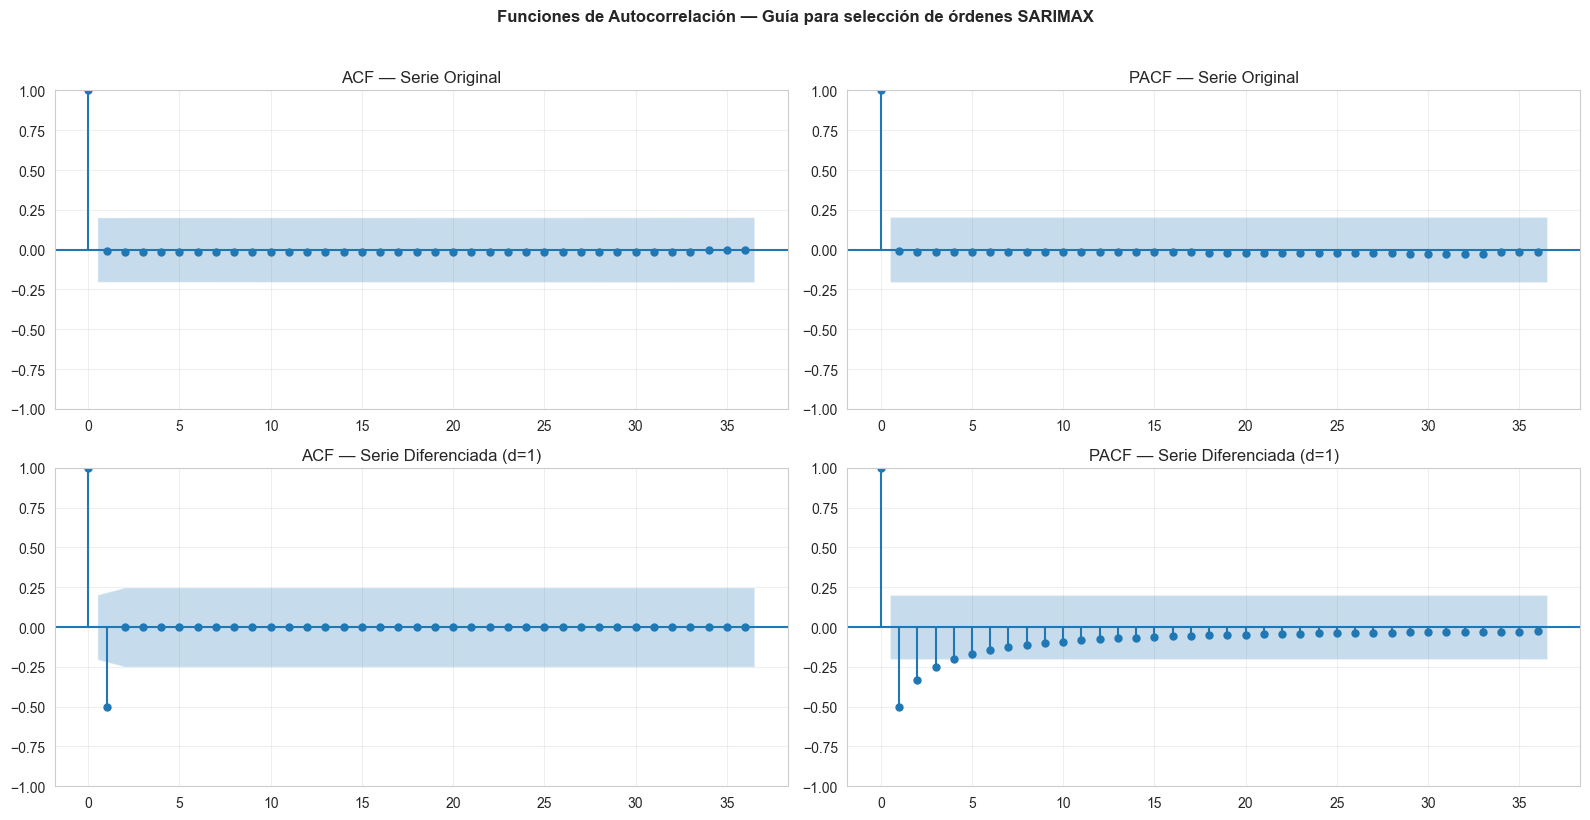

In [12]:
# ACF y PACF de la serie original y diferenciada
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(y_train, lags=36, ax=axes[0, 0], title="ACF — Serie Original")
plot_pacf(y_train, lags=36, ax=axes[0, 1], title="PACF — Serie Original", method="ywm")
plot_acf(y_diff, lags=36, ax=axes[1, 0], title="ACF — Serie Diferenciada (d=1)")
plot_pacf(y_diff, lags=36, ax=axes[1, 1], title="PACF — Serie Diferenciada (d=1)", method="ywm")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.suptitle("Funciones de Autocorrelación — Guía para selección de órdenes SARIMAX",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Modelo SARIMAX Baseline (sin tuning)

Se ajusta un SARIMAX con configuración inicial estándar `(1,1,1)(1,1,1,12)` para establecer una línea base de comparación antes de la optimización.

In [13]:
# ── Modelo Baseline ──
baseline_order = (1, 1, 1)
baseline_seasonal = (1, 1, 1, 12)

print(f"Ajustando SARIMAX baseline: order={baseline_order}, seasonal_order={baseline_seasonal}")
print(f"Exógena: {EXOG_COL} (escalada)\n")

baseline_model = SARIMAX(
    y_train,
    exog=exog_train_sc,
    order=baseline_order,
    seasonal_order=baseline_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(baseline_model.summary())

# Métricas provisionales con forecast directo (se recalculan con rolling en sección 9)
forecast_baseline = np.clip(
    baseline_model.forecast(steps=len(y_test), exog=exog_test_sc).values, 0, None
)

mae_bl = mean_absolute_error(y_test, forecast_baseline)
rmse_bl = np.sqrt(mean_squared_error(y_test, forecast_baseline))
smape_bl = smape(y_test, forecast_baseline)

print(f"\n{'─'*50}")
print(f"  BASELINE SARIMAX{baseline_order}x{baseline_seasonal} (forecast directo)")
print(f"{'─'*50}")
print(f"  MAE:      {mae_bl:.4f}")
print(f"  RMSE:     {rmse_bl:.4f}")
print(f"  SMAPE(%): {smape_bl:.2f}%")
print(f"\n  (Se recalculará con rolling 1-step-ahead en la sección 9)")

Ajustando SARIMAX baseline: order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)
Exógena: total_dosis_lag_3m (escalada)

                                     SARIMAX Results                                      
Dep. Variable:                    casos_sarampion   No. Observations:                   94
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -209.576
Date:                            Wed, 04 Mar 2026   AIC                            431.152
Time:                                    20:44:31   BIC                            444.380
Sample:                                         0   HQIC                           436.386
                                             - 94                                         
Covariance Type:                              opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

---
## 8. Selección de Hiperparámetros con Validación Temporal (TimeSeriesSplit)

Se realiza una **búsqueda exhaustiva** sobre combinaciones de:
- **Órdenes no estacionales:** $p \in \{0,1,2\}$, $d \in \{0,1\}$, $q \in \{0,1,2\}$
- **Órdenes estacionales:** $P \in \{0,1\}$, $D \in \{0,1\}$, $Q \in \{0,1\}$, $s=12$

Criterios de calidad:
- **TimeSeriesSplit** con 5 folds y ventana de validación de 12 meses (garantiza mínimo ~34 obs de entrenamiento por fold, adecuado para S=12).
- **Selección por score compuesto:** promedio de rangos normalizados de RMSE, MAE y SMAPE, para equilibrar precisión y robustez (evita seleccionar modelos que optimizan solo una métrica a costa de otra).

In [14]:
# ── Grid de búsqueda ──
p_range = [0, 1, 2]
d_range = [0, 1]
q_range = [0, 1, 2]
P_range = [0, 1]
D_range = [0, 1]
Q_range = [0, 1]
S = 12  # Periodicidad mensual

# Generar todas las combinaciones
all_combinations = list(product(p_range, d_range, q_range, P_range, D_range, Q_range))
print(f"Total de combinaciones a evaluar: {len(all_combinations)}")

# Configuración de TimeSeriesSplit
# test_size=12 → cada fold valida con 12 meses; mínimo de entrenamiento ≈ 34 obs (> 2×S)
N_SPLITS = 5
TEST_SIZE = 12
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

print(f"Validación temporal: TimeSeriesSplit con {N_SPLITS} folds, ventana de validación = {TEST_SIZE} meses")
print(f"Tamaño mínimo de entrenamiento por fold: ~{len(y_train) - N_SPLITS * TEST_SIZE} obs")
print(f"\nIniciando búsqueda exhaustiva de hiperparámetros...\n")

Total de combinaciones a evaluar: 144
Validación temporal: TimeSeriesSplit con 5 folds, ventana de validación = 12 meses
Tamaño mínimo de entrenamiento por fold: ~34 obs

Iniciando búsqueda exhaustiva de hiperparámetros...



In [15]:
# ── Búsqueda exhaustiva con TimeSeriesSplit ──
results_grid = []
total = len(all_combinations)

y_train_arr = y_train.values
exog_train_arr = exog_train_sc.values

for idx, (p, d, q, P, D, Q) in enumerate(all_combinations):
    order = (p, d, q)
    seasonal_order = (P, D, Q, S)

    fold_rmses = []
    fold_maes = []
    fold_smapes = []
    fold_aics = []
    success = True

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(y_train_arr)):
        y_tr = y_train_arr[train_idx]
        y_val = y_train_arr[val_idx]
        exog_tr = exog_train_arr[train_idx]
        exog_val = exog_train_arr[val_idx]

        try:
            model = SARIMAX(
                y_tr,
                exog=exog_tr,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=300)

            preds = np.clip(
                model.forecast(steps=len(y_val), exog=exog_val), 0, None
            )

            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
            fold_maes.append(mean_absolute_error(y_val, preds))
            fold_smapes.append(smape(y_val, preds))
            fold_aics.append(model.aic)
        except Exception:
            success = False
            break

    if success and len(fold_rmses) == N_SPLITS:
        results_grid.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "mean_rmse_cv": np.mean(fold_rmses),
            "std_rmse_cv": np.std(fold_rmses),
            "mean_mae_cv": np.mean(fold_maes),
            "mean_smape_cv": np.mean(fold_smapes),
            "mean_aic_cv": np.mean(fold_aics),
        })

    if (idx + 1) % 20 == 0 or idx == total - 1:
        print(f"  Progreso: {idx + 1}/{total} combinaciones evaluadas | "
              f"{len(results_grid)} exitosas")

print(f"\n✓ Búsqueda completada: {len(results_grid)} combinaciones válidas de {total} totales.")

  Progreso: 20/144 combinaciones evaluadas | 20 exitosas
  Progreso: 40/144 combinaciones evaluadas | 40 exitosas
  Progreso: 60/144 combinaciones evaluadas | 60 exitosas
  Progreso: 80/144 combinaciones evaluadas | 80 exitosas
  Progreso: 100/144 combinaciones evaluadas | 100 exitosas
  Progreso: 120/144 combinaciones evaluadas | 120 exitosas
  Progreso: 140/144 combinaciones evaluadas | 140 exitosas
  Progreso: 144/144 combinaciones evaluadas | 144 exitosas

✓ Búsqueda completada: 144 combinaciones válidas de 144 totales.


In [16]:
# ── Ranking de mejores configuraciones con score compuesto ──
df_grid = pd.DataFrame(results_grid)

# Score compuesto: promedio de rangos normalizados (RMSE, MAE, SMAPE)
df_grid["rank_rmse"] = df_grid["mean_rmse_cv"].rank()
df_grid["rank_mae"] = df_grid["mean_mae_cv"].rank()
df_grid["rank_smape"] = df_grid["mean_smape_cv"].rank()
df_grid["composite_score"] = (df_grid["rank_rmse"] + df_grid["rank_mae"] + df_grid["rank_smape"]) / 3
df_grid = df_grid.sort_values("composite_score").reset_index(drop=True)

print("="*90)
print("  TOP 15 CONFIGURACIONES SARIMAX (por score compuesto: RMSE + MAE + SMAPE)")
print("="*90)
display(
    df_grid.head(15)[
        ["order", "seasonal_order", "mean_rmse_cv", "std_rmse_cv", "mean_mae_cv",
         "mean_smape_cv", "mean_aic_cv", "composite_score"]
    ].rename(columns={
        "mean_rmse_cv": "RMSE_CV",
        "std_rmse_cv": "RMSE_CV (std)",
        "mean_mae_cv": "MAE_CV",
        "mean_smape_cv": "SMAPE_CV(%)",
        "mean_aic_cv": "AIC_CV",
        "composite_score": "Score",
    })
)

# Mejor configuración
best_config = df_grid.iloc[0]
print(f"\n★ Mejor configuración encontrada (score compuesto):")
print(f"  order:          {best_config['order']}")
print(f"  seasonal_order: {best_config['seasonal_order']}")
print(f"  RMSE CV medio:  {best_config['mean_rmse_cv']:.4f} ± {best_config['std_rmse_cv']:.4f}")
print(f"  MAE CV medio:   {best_config['mean_mae_cv']:.4f}")
print(f"  SMAPE CV medio: {best_config['mean_smape_cv']:.2f}%")
print(f"  AIC CV medio:   {best_config['mean_aic_cv']:.2f}")
print(f"  Score compuesto: {best_config['composite_score']:.2f}")

  TOP 15 CONFIGURACIONES SARIMAX (por score compuesto: RMSE + MAE + SMAPE)


,order,seasonal_order,RMSE_CV,RMSE_CV (std),MAE_CV,SMAPE_CV(%),AIC_CV,Score
0,"(2, 0, 2)","(0, 0, 1, 12)",0.650914,0.603419,0.410273,56.556103,408.745937,12.333333
1,"(1, 0, 2)","(1, 0, 1, 12)",0.668978,0.632600,0.421578,56.517739,452.681472,12.666667
2,"(1, 0, 1)","(0, 0, 1, 12)",0.660516,0.576581,0.415645,56.556565,453.423235,13.333333
3,"(1, 0, 1)","(1, 0, 1, 12)",0.645672,0.598672,0.408982,58.184980,449.722650,14.666667
4,"(1, 0, 2)","(0, 0, 1, 12)",0.673690,0.636405,0.422109,56.591940,456.402824,15.333333
5,"(2, 0, 1)","(0, 0, 1, 12)",1.885843,3.008266,1.026621,53.218033,441.236486,22.333333
6,"(0, 0, 1)","(0, 1, 0, 12)",3.136847,4.285185,1.116472,56.551189,315.065941,31.000000
7,"(0, 0, 1)","(1, 1, 1, 12)",4.878550,2.308944,1.870298,53.330230,223.549549,32.000000
8,"(0, 0, 0)","(0, 1, 0, 12)",2.946707,4.402620,1.024837,58.226793,319.346599,34.666667
9,"(0, 0, 2)","(1, 1, 1, 12)",4.273582,1.565494,1.964772,54.996630,218.544032,35.000000



★ Mejor configuración encontrada (score compuesto):
  order:          (2, 0, 2)
  seasonal_order: (0, 0, 1, 12)
  RMSE CV medio:  0.6509 ± 0.6034
  MAE CV medio:   0.4103
  SMAPE CV medio: 56.56%
  AIC CV medio:   408.75
  Score compuesto: 12.33


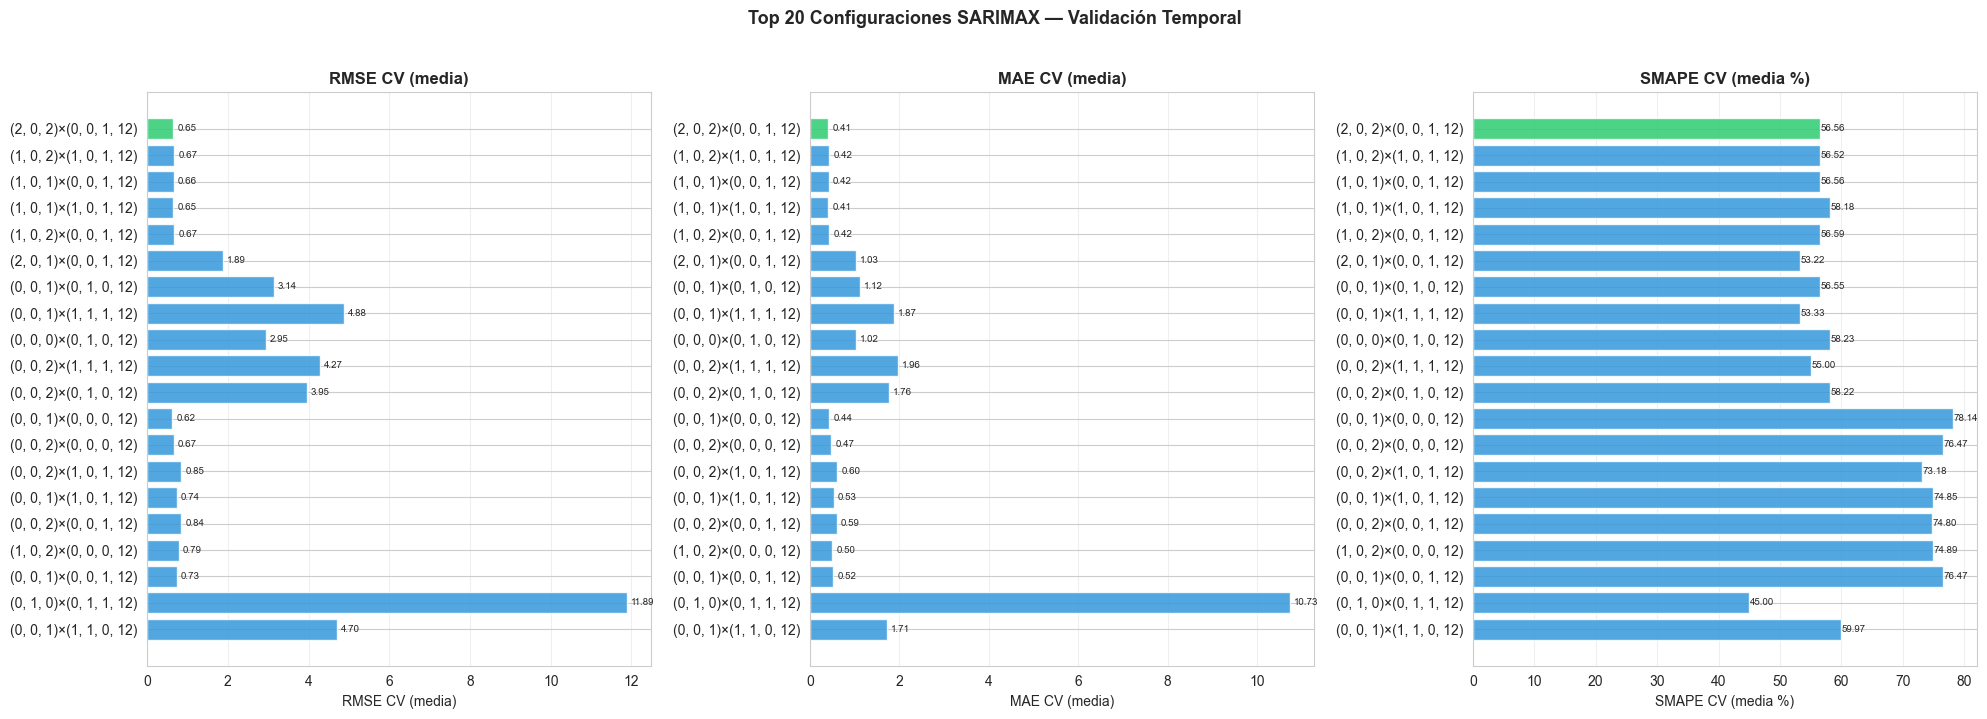

In [17]:
# ── Visualización del ranking ──
top_n = min(20, len(df_grid))
df_top = df_grid.head(top_n).copy()
df_top["config_label"] = df_top.apply(
    lambda r: f"{r['order']}×{r['seasonal_order']}", axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (metric, title) in enumerate([
    ("mean_rmse_cv", "RMSE CV (media)"),
    ("mean_mae_cv", "MAE CV (media)"),
    ("mean_smape_cv", "SMAPE CV (media %)"),
]):
    ax = axes[i]
    colors = ["#2ecc71" if j == 0 else "#3498db" for j in range(top_n)]
    bars = ax.barh(df_top["config_label"][::-1], df_top[metric][::-1], color=colors[::-1], alpha=0.85)
    ax.set_xlabel(title)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    for bar, val in zip(bars, df_top[metric][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=7)

plt.suptitle(f"Top {top_n} Configuraciones SARIMAX — Validación Temporal",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Entrenamiento del Modelo Óptimo y Evaluación en Test

Se entrena el SARIMAX con la mejor configuración encontrada sobre **todo el conjunto de entrenamiento** y se evalúa con dos estrategias:

1. **Forecast directo** (multi-step): predicción de los 60 meses de una sola vez.2. **Rolling 1-step-ahead**: se avanza mes a mes incorporando el valor real observado (sin re-estimar parámetros), lo que evita la acumulación de error.

In [18]:
# ── Entrenar modelo óptimo ──
best_order = best_config["order"]
best_seasonal = best_config["seasonal_order"]

print(f"Entrenando modelo óptimo: SARIMAX{best_order}x{best_seasonal}")
print(f"Exógena: {EXOG_COL} (escalada)")
print(f"Train: {len(y_train)} obs | Test: {len(y_test)} obs\n")

optimal_model = SARIMAX(
    y_train,
    exog=exog_train_sc,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(optimal_model.summary())

Entrenando modelo óptimo: SARIMAX(2, 0, 2)x(0, 0, 1, 12)
Exógena: total_dosis_lag_3m (escalada)
Train: 94 obs | Test: 60 obs

                                      SARIMAX Results                                       
Dep. Variable:                      casos_sarampion   No. Observations:                   94
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 12)   Log Likelihood                -233.050
Date:                              Wed, 04 Mar 2026   AIC                            480.100
Time:                                      20:47:49   BIC                            496.686
Sample:                                           0   HQIC                           486.745
                                               - 94                                         
Covariance Type:                                opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

In [19]:
# ── Evaluación 1: Forecast directo (multi-step) ──
forecast_direct = np.clip(
    optimal_model.forecast(steps=len(y_test), exog=exog_test_sc).values, 0, None
)

# ── Evaluación 2: Rolling one-step-ahead (sin re-estimar parámetros) ──
# Re-indexar y_test y exog para que los índices continúen del train
n_train = len(y_train)
y_test_reindexed = y_test.copy()
y_test_reindexed.index = range(n_train, n_train + len(y_test))

exog_test_reindexed = exog_test_sc.copy()
exog_test_reindexed.index = range(n_train, n_train + len(y_test))

rolling_preds = []
current_model = optimal_model
for i in range(len(y_test)):
    idx_i = n_train + i
    fc = current_model.forecast(steps=1, exog=exog_test_reindexed.iloc[[i]])
    rolling_preds.append(np.clip(fc.values[0], 0, None))
    # Incorporar observación real y avanzar el estado del modelo
    if i < len(y_test) - 1:
        current_model = current_model.append(
            y_test_reindexed.iloc[[i]], exog=exog_test_reindexed.iloc[[i]], refit=False
        )
forecast_rolling = np.array(rolling_preds)

# También para el baseline
rolling_bl = []
current_bl = baseline_model
for i in range(len(y_test)):
    fc = current_bl.forecast(steps=1, exog=exog_test_reindexed.iloc[[i]])
    rolling_bl.append(np.clip(fc.values[0], 0, None))
    if i < len(y_test) - 1:
        current_bl = current_bl.append(
            y_test_reindexed.iloc[[i]], exog=exog_test_reindexed.iloc[[i]], refit=False
        )
forecast_bl_rolling = np.array(rolling_bl)

# Usar el rolling como forecast principal
forecast_optimal = forecast_rolling
forecast_baseline = forecast_bl_rolling

# Métricas
mae_opt = mean_absolute_error(y_test, forecast_optimal)
rmse_opt = np.sqrt(mean_squared_error(y_test, forecast_optimal))
smape_opt = smape(y_test, forecast_optimal)

mae_bl = mean_absolute_error(y_test, forecast_baseline)
rmse_bl = np.sqrt(mean_squared_error(y_test, forecast_baseline))
smape_bl = smape(y_test, forecast_baseline)

mae_dir = mean_absolute_error(y_test, forecast_direct)
rmse_dir = np.sqrt(mean_squared_error(y_test, forecast_direct))
smape_dir = smape(y_test, forecast_direct)

print("="*80)
print("  RESULTADOS — EVALUACIÓN EN TEST")
print("="*80)
print(f"\n  {'Métrica':<12s} {'BL rolling':>14s} {'Ópt rolling':>14s} {'Ópt directo':>14s}")
print(f"  {'─'*58}")
print(f"  {'MAE':<12s} {mae_bl:>14.4f} {mae_opt:>14.4f} {mae_dir:>14.4f}")
print(f"  {'RMSE':<12s} {rmse_bl:>14.4f} {rmse_opt:>14.4f} {rmse_dir:>14.4f}")
print(f"  {'SMAPE(%)':<12s} {smape_bl:>14.2f} {smape_opt:>14.2f} {smape_dir:>14.2f}")
print(f"\n  Nota: Se usa rolling 1-step-ahead como métrica principal.")
print(f"  El forecast directo (60 pasos) se muestra como referencia.")
print(f"\n  Δ (Óptimo rolling - Baseline rolling):")
print(f"  {'MAE':<12s} {mae_opt - mae_bl:>+14.4f}")
print(f"  {'RMSE':<12s} {rmse_opt - rmse_bl:>+14.4f}")
print(f"  {'SMAPE(%)':<12s} {smape_opt - smape_bl:>+14.2f}")

  RESULTADOS — EVALUACIÓN EN TEST

  Métrica          BL rolling    Ópt rolling    Ópt directo
  ──────────────────────────────────────────────────────────
  MAE                  6.9103         3.5000         3.5123
  RMSE                15.1277        14.3991        14.3938
  SMAPE(%)              86.87          16.67          64.89

  Nota: Se usa rolling 1-step-ahead como métrica principal.
  El forecast directo (60 pasos) se muestra como referencia.

  Δ (Óptimo rolling - Baseline rolling):
  MAE                 -3.4103
  RMSE                -0.7286
  SMAPE(%)             -70.20


---
## 10. Visualización: Predicción vs. Observados

Se grafican los resultados para visualizar el ajuste del modelo y su capacidad de pronóstico.

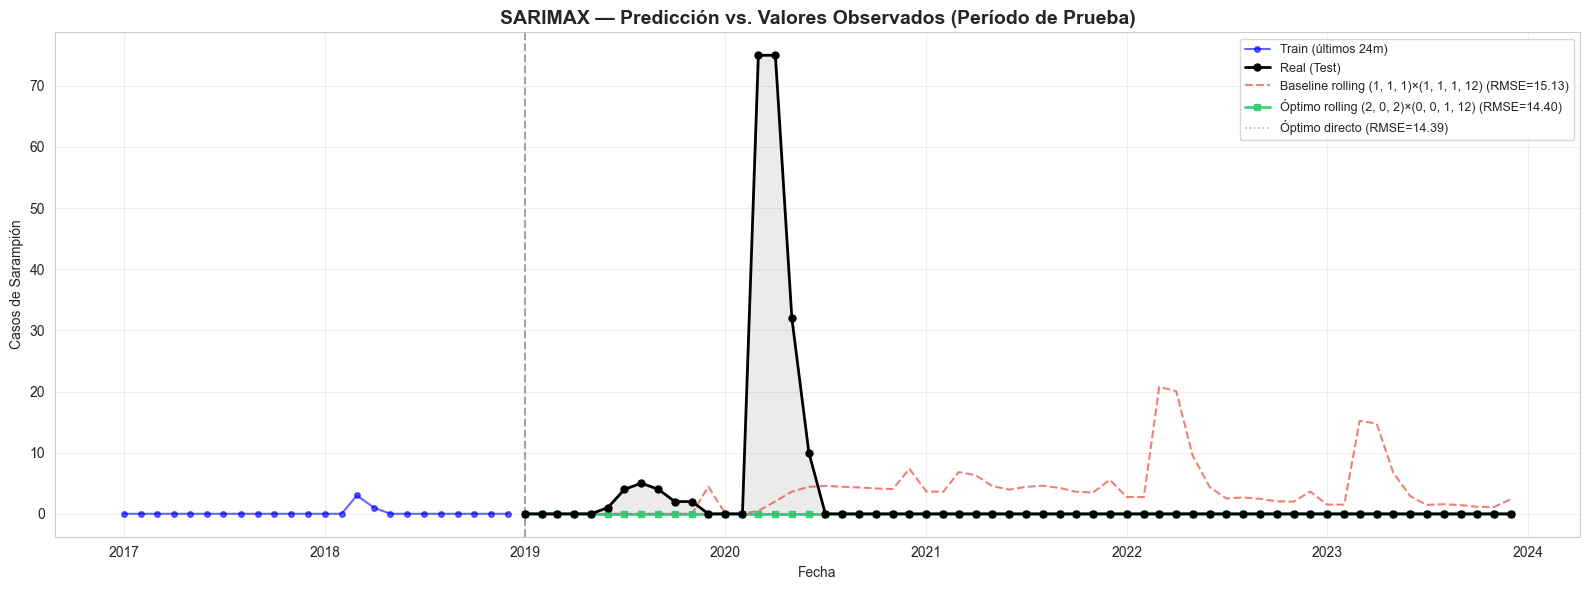

In [20]:
# ── Gráfica principal: Forecast vs Real ──
fig, ax = plt.subplots(figsize=(16, 6))

# Entrenamiento (últimos 24 meses para contexto)
context_n = min(24, len(y_train))
ax.plot(
    dates_train.iloc[-context_n:], y_train.iloc[-context_n:],
    "b-o", ms=4, lw=1.5, alpha=0.6, label="Train (últimos 24m)"
)

# Test real
ax.plot(dates_test, y_test, "k-o", ms=5, lw=2, label="Real (Test)", zorder=5)

# Baseline rolling
ax.plot(
    dates_test, forecast_baseline, "--", color="#e74c3c", lw=1.5,
    alpha=0.7, label=f"Baseline rolling {baseline_order}×{baseline_seasonal} (RMSE={rmse_bl:.2f})"
)

# Óptimo rolling
ax.plot(
    dates_test, forecast_optimal, "-s", color="#2ecc71", ms=5, lw=2,
    alpha=0.9, label=f"Óptimo rolling {best_order}×{best_seasonal} (RMSE={rmse_opt:.2f})"
)

# Óptimo directo (referencia)
ax.plot(
    dates_test, forecast_direct, ":", color="#9b59b6", lw=1.2,
    alpha=0.5, label=f"Óptimo directo (RMSE={rmse_dir:.2f})"
)

ax.axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls="--", lw=1.5, alpha=0.7)
ax.fill_between(dates_test, 0, y_test, alpha=0.08, color="black")

ax.set_title("SARIMAX — Predicción vs. Valores Observados (Período de Prueba)",
             fontweight="bold", fontsize=14)
ax.set_ylabel("Casos de Sarampión")
ax.set_xlabel("Fecha")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

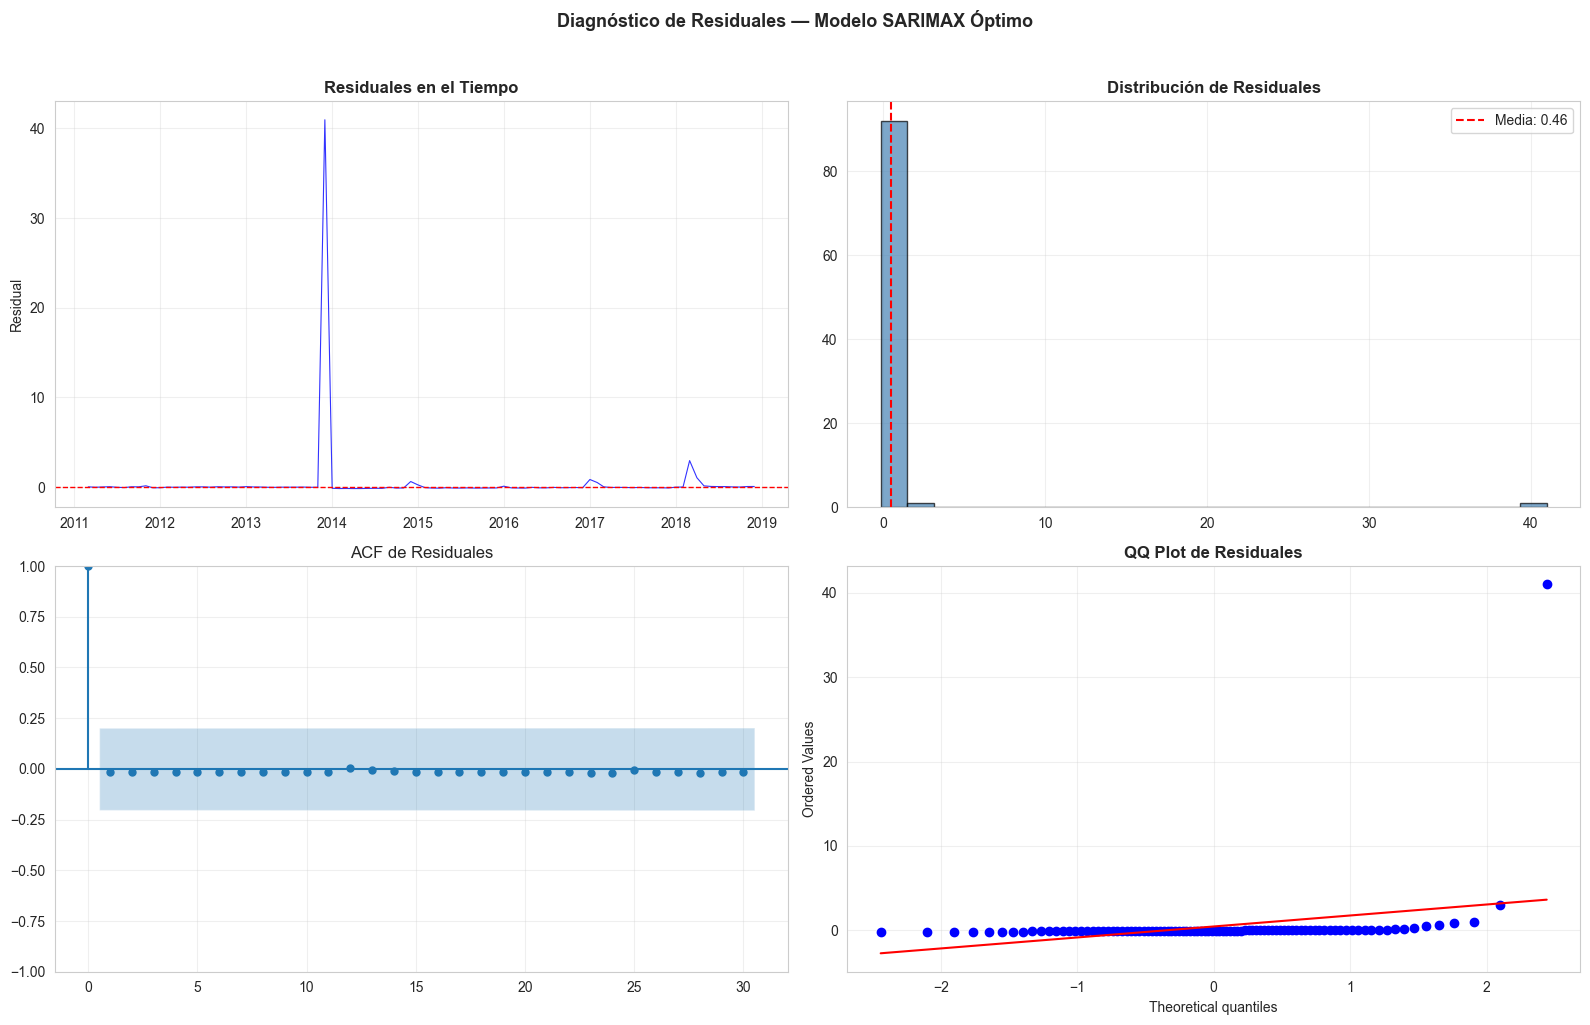

In [21]:
# ── Residuales del modelo óptimo (in-sample) ──
residuals = optimal_model.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuales en el tiempo
axes[0, 0].plot(dates_train, residuals, "b-", lw=0.8, alpha=0.8)
axes[0, 0].axhline(0, color="red", ls="--", lw=1)
axes[0, 0].set_title("Residuales en el Tiempo", fontweight="bold")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(True, alpha=0.3)

# Histograma de residuales
axes[0, 1].hist(residuals, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 1].axvline(residuals.mean(), color="red", ls="--", lw=1.5,
                    label=f"Media: {residuals.mean():.2f}")
axes[0, 1].set_title("Distribución de Residuales", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ACF de residuales
plot_acf(residuals, lags=30, ax=axes[1, 0], title="ACF de Residuales")
axes[1, 0].grid(True, alpha=0.3)

# QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ Plot de Residuales", fontweight="bold")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Diagnóstico de Residuales — Modelo SARIMAX Óptimo",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# ── Error por período (análisis granular) ──
df_eval = pd.DataFrame({
    "fecha": dates_test.values,
    "real": y_test.values,
    "prediccion": forecast_optimal,
    "error": y_test.values - forecast_optimal,
    "abs_error": np.abs(y_test.values - forecast_optimal),
})
df_eval["anio"] = df_eval["fecha"].dt.year
df_eval["mes"] = df_eval["fecha"].dt.month

print("="*70)
print("  DETALLE DE PREDICCIONES — PERÍODO DE PRUEBA")
print("="*70)
display(df_eval[["fecha", "real", "prediccion", "error", "abs_error"]].round(2))

# Métricas por año
print("\n" + "─"*50)
print("  MÉTRICAS POR AÑO")
print("─"*50)
for anio in sorted(df_eval["anio"].unique()):
    mask = df_eval["anio"] == anio
    y_r = df_eval.loc[mask, "real"].values
    y_p = df_eval.loc[mask, "prediccion"].values
    print(f"  {anio}: MAE={mean_absolute_error(y_r, y_p):.4f} | "
          f"RMSE={np.sqrt(mean_squared_error(y_r, y_p)):.4f} | "
          f"SMAPE={smape(y_r, y_p):.2f}%")

  DETALLE DE PREDICCIONES — PERÍODO DE PRUEBA


,fecha,real,prediccion,error,abs_error
0,2019-01-01,0.0,0.0,0.0,0.0
1,2019-02-01,0.0,0.0,0.0,0.0
2,2019-03-01,0.0,0.0,0.0,0.0
3,2019-04-01,0.0,0.0,0.0,0.0
4,2019-05-01,0.0,0.0,0.0,0.0
5,2019-06-01,1.0,0.0,1.0,1.0
6,2019-07-01,4.0,0.0,4.0,4.0
7,2019-08-01,5.0,0.0,5.0,5.0
8,2019-09-01,4.0,0.0,4.0,4.0
9,2019-10-01,2.0,0.0,2.0,2.0



──────────────────────────────────────────────────
  MÉTRICAS POR AÑO
──────────────────────────────────────────────────
  2019: MAE=1.5000 | RMSE=2.3452 | SMAPE=50.00%
  2020: MAE=16.0000 | RMSE=32.1118 | SMAPE=33.33%
  2021: MAE=0.0000 | RMSE=0.0000 | SMAPE=0.00%
  2022: MAE=0.0000 | RMSE=0.0000 | SMAPE=0.00%
  2023: MAE=0.0000 | RMSE=0.0000 | SMAPE=0.00%


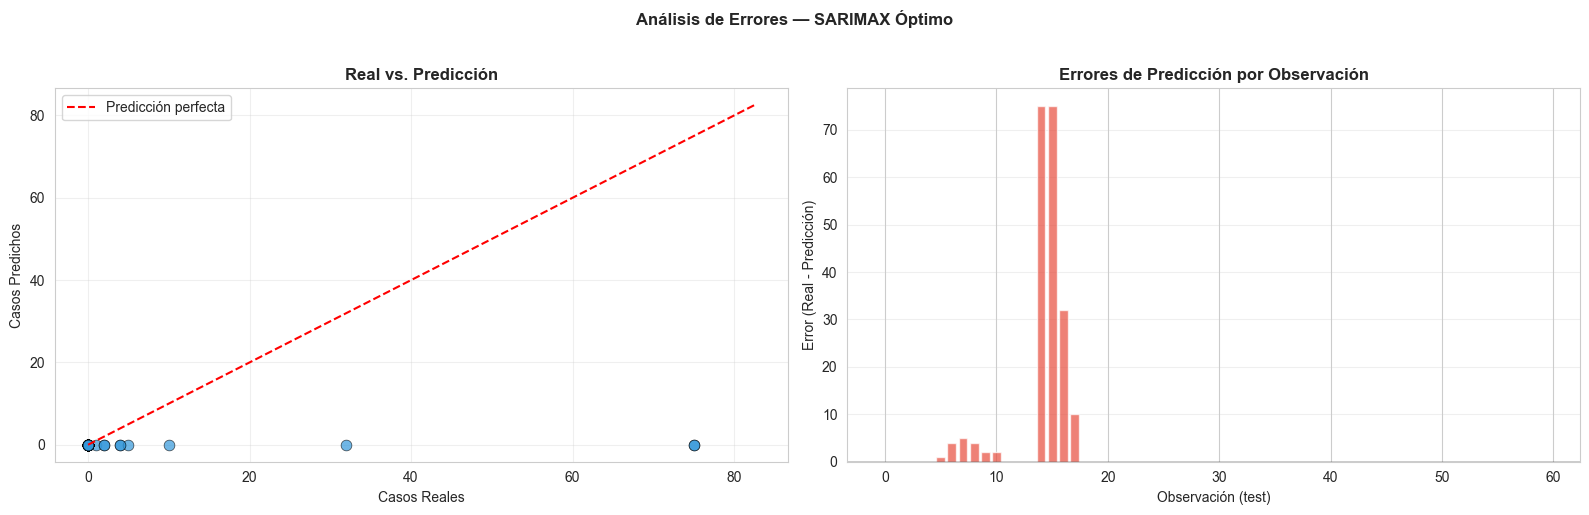

In [23]:
# ── Gráfica de errores por mes ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: Real vs Predicción
ax = axes[0]
ax.scatter(df_eval["real"], df_eval["prediccion"], c="#3498db", s=60, alpha=0.7,
           edgecolors="black", linewidths=0.5)
max_val = max(df_eval["real"].max(), df_eval["prediccion"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], "r--", lw=1.5, label="Predicción perfecta")
ax.set_xlabel("Casos Reales")
ax.set_ylabel("Casos Predichos")
ax.set_title("Real vs. Predicción", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# Barras: Error absoluto por observación
ax = axes[1]
colors = ["#e74c3c" if e > 0 else "#2ecc71" for e in df_eval["error"]]
ax.bar(range(len(df_eval)), df_eval["error"], color=colors, alpha=0.7)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Observación (test)")
ax.set_ylabel("Error (Real - Predicción)")
ax.set_title("Errores de Predicción por Observación", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Análisis de Errores — SARIMAX Óptimo", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Tabla Resumen de Resultados

Comparativa final entre el modelo **baseline** y el modelo **optimizado**, junto con los resultados de los demás modelos obtenidos en el Avance 4.

  COMPARATIVA SARIMAX — BASELINE vs ÓPTIMO


,Modelo,Evaluación,MAE,RMSE,SMAPE(%),AIC,BIC
0,"Baseline rolling (1, 1, 1)×(1, 1, 1, 12)",Rolling 1-step,6.9103,15.1277,86.87,431.15,444.38
1,"Óptimo rolling (2, 0, 2)×(0, 0, 1, 12)",Rolling 1-step,3.5000,14.3991,16.67,480.10,496.69
2,"Óptimo directo (2, 0, 2)×(0, 0, 1, 12)",Multi-step (60),3.5123,14.3938,64.89,480.10,496.69


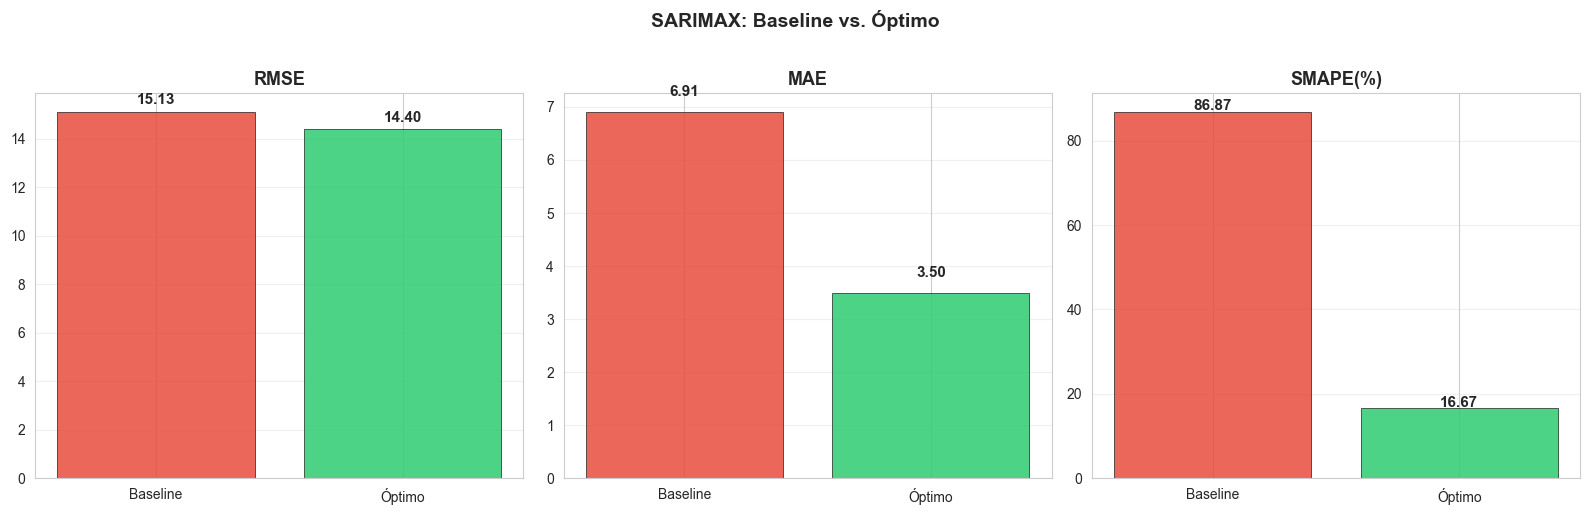

In [24]:
# ── Tabla comparativa SARIMAX: Baseline vs Óptimo (rolling 1-step-ahead) ──
resultados_sarimax = pd.DataFrame([
    {
        "Modelo": f"Baseline rolling {baseline_order}×{baseline_seasonal}",
        "Evaluación": "Rolling 1-step",
        "MAE": round(mae_bl, 4),
        "RMSE": round(rmse_bl, 4),
        "SMAPE(%)": round(smape_bl, 2),
        "AIC": round(baseline_model.aic, 2),
        "BIC": round(baseline_model.bic, 2),
    },
    {
        "Modelo": f"Óptimo rolling {best_order}×{best_seasonal}",
        "Evaluación": "Rolling 1-step",
        "MAE": round(mae_opt, 4),
        "RMSE": round(rmse_opt, 4),
        "SMAPE(%)": round(smape_opt, 2),
        "AIC": round(optimal_model.aic, 2),
        "BIC": round(optimal_model.bic, 2),
    },
    {
        "Modelo": f"Óptimo directo {best_order}×{best_seasonal}",
        "Evaluación": "Multi-step (60)",
        "MAE": round(mae_dir, 4),
        "RMSE": round(rmse_dir, 4),
        "SMAPE(%)": round(smape_dir, 2),
        "AIC": round(optimal_model.aic, 2),
        "BIC": round(optimal_model.bic, 2),
    },
])

print("="*90)
print("  COMPARATIVA SARIMAX — BASELINE vs ÓPTIMO")
print("="*90)
display(resultados_sarimax)

# Gráfica comparativa (solo rolling: Baseline vs Óptimo)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["RMSE", "MAE", "SMAPE(%)"]
colors = ["#e74c3c", "#2ecc71"]
df_rolling = resultados_sarimax[resultados_sarimax["Evaluación"] == "Rolling 1-step"]

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(
        ["Baseline", "Óptimo"],
        df_rolling[metric].values,
        color=colors,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )
    for bar, val in zip(bars, df_rolling[metric].values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.2f}", ha="center", fontweight="bold", fontsize=11)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("SARIMAX: Baseline vs. Óptimo", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Comparativa con Resultados del Avance 4

Se importan los resultados de métricas obtenidos en el Avance 4 (todos los modelos: ML Directo, ML Recursivo y Series de Tiempo) para comparar con el SARIMAX optimizado en este notebook, el cual utiliza **únicamente vacunas desplazadas** como variable exógena.

In [26]:
# ── Importar resultados del Avance 4 ──
avance4_path =  Path("../../..") / "data" / "processed" / "resultados_avance4_metricas.csv"
df_avance4 = pd.read_csv(avance4_path)

print("="*90)
print("  RESULTADOS DEL AVANCE 4 (todos los modelos)")
print("="*90)
display(df_avance4.sort_values(by=["Enfoque", "Horizonte", "RMSE"]))

# Agregar resultado del SARIMAX optimizado de este notebook
sarimax_nuevo = pd.DataFrame([{
    "Enfoque": "Series de Tiempo",
    "Modelo": f"SARIMAX Óptimo (solo vacunas) {best_order}×{best_seasonal}",
    "Horizonte": "Completo",
    "MAE": round(mae_opt, 4),
    "RMSE": round(rmse_opt, 4),
    "SMAPE(%)": round(smape_opt, 2),
}])

df_comparativa = pd.concat([df_avance4, sarimax_nuevo], ignore_index=True)

print("\n" + "="*90)
print("  COMPARATIVA INTEGRAL — AVANCE 4 + SARIMAX OPTIMIZADO (este notebook)")
print("="*90)
display(df_comparativa.sort_values("RMSE"))

# Mejor modelo general
print("\n" + "─"*70)
print("  RANKING GENERAL (menor RMSE)")
print("─"*70)
for i, row in df_comparativa.sort_values("RMSE").iterrows():
    h_label = f"h={row['Horizonte']}" if row['Horizonte'] != "Completo" else "Completo"
    print(f"  {row['Enfoque']} — {row['Modelo']} ({h_label}) → "
          f"RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, "
          f"SMAPE={row['SMAPE(%)']:.2f}%")

  RESULTADOS DEL AVANCE 4 (todos los modelos)


,Enfoque,Modelo,Horizonte,MAE,RMSE,SMAPE(%)
1,Directo,LightGBM,1,3.8523,14.4105,78.11
2,Directo,RandomForest,1,3.8604,14.4161,97.92
0,Directo,XGBoost,1,3.8635,14.4378,97.31
4,Directo,LightGBM,2,3.9495,14.5849,88.62
3,Directo,XGBoost,2,3.9212,14.6203,95.70
5,Directo,RandomForest,2,4.0211,14.6378,96.73
7,Directo,LightGBM,3,3.9484,14.6870,69.19
8,Directo,RandomForest,3,3.9262,14.7405,97.40
6,Directo,XGBoost,3,3.7454,14.7641,99.75
12,Recursivo,LightGBM,1,3.9870,14.5343,77.51



  COMPARATIVA INTEGRAL — AVANCE 4 + SARIMAX OPTIMIZADO (este notebook)


,Enfoque,Modelo,Horizonte,MAE,RMSE,SMAPE(%)
19,Series de Tiempo,SARIMAX (tuned),Completo,3.5697,10.9467,33.48
20,Series de Tiempo,Prophet (tuned),Completo,3.3091,11.4666,10.30
18,Series de Tiempo,HoltWinters híbrido,Completo,3.4262,11.9283,18.61
21,Series de Tiempo,"SARIMAX Óptimo (solo vacunas) (2, 0, 2)×(0, 0,...",Completo,3.5000,14.3991,16.67
1,Directo,LightGBM,1,3.8523,14.4105,78.11
2,Directo,RandomForest,1,3.8604,14.4161,97.92
0,Directo,XGBoost,1,3.8635,14.4378,97.31
12,Recursivo,LightGBM,1,3.9870,14.5343,77.51
9,Recursivo,XGBoost,1,3.9347,14.5573,97.53
15,Recursivo,RandomForest,1,4.0532,14.5810,98.91



──────────────────────────────────────────────────────────────────────
  RANKING GENERAL (menor RMSE)
──────────────────────────────────────────────────────────────────────
  Series de Tiempo — SARIMAX (tuned) (Completo) → RMSE=10.9467, MAE=3.5697, SMAPE=33.48%
  Series de Tiempo — Prophet (tuned) (Completo) → RMSE=11.4666, MAE=3.3091, SMAPE=10.30%
  Series de Tiempo — HoltWinters híbrido (Completo) → RMSE=11.9283, MAE=3.4262, SMAPE=18.61%
  Series de Tiempo — SARIMAX Óptimo (solo vacunas) (2, 0, 2)×(0, 0, 1, 12) (Completo) → RMSE=14.3991, MAE=3.5000, SMAPE=16.67%
  Directo — LightGBM (h=1) → RMSE=14.4105, MAE=3.8523, SMAPE=78.11%
  Directo — RandomForest (h=1) → RMSE=14.4161, MAE=3.8604, SMAPE=97.92%
  Directo — XGBoost (h=1) → RMSE=14.4378, MAE=3.8635, SMAPE=97.31%
  Recursivo — LightGBM (h=1) → RMSE=14.5343, MAE=3.9870, SMAPE=77.51%
  Recursivo — XGBoost (h=1) → RMSE=14.5573, MAE=3.9347, SMAPE=97.53%
  Recursivo — RandomForest (h=1) → RMSE=14.5810, MAE=4.0532, SMAPE=98.91%
  Direct

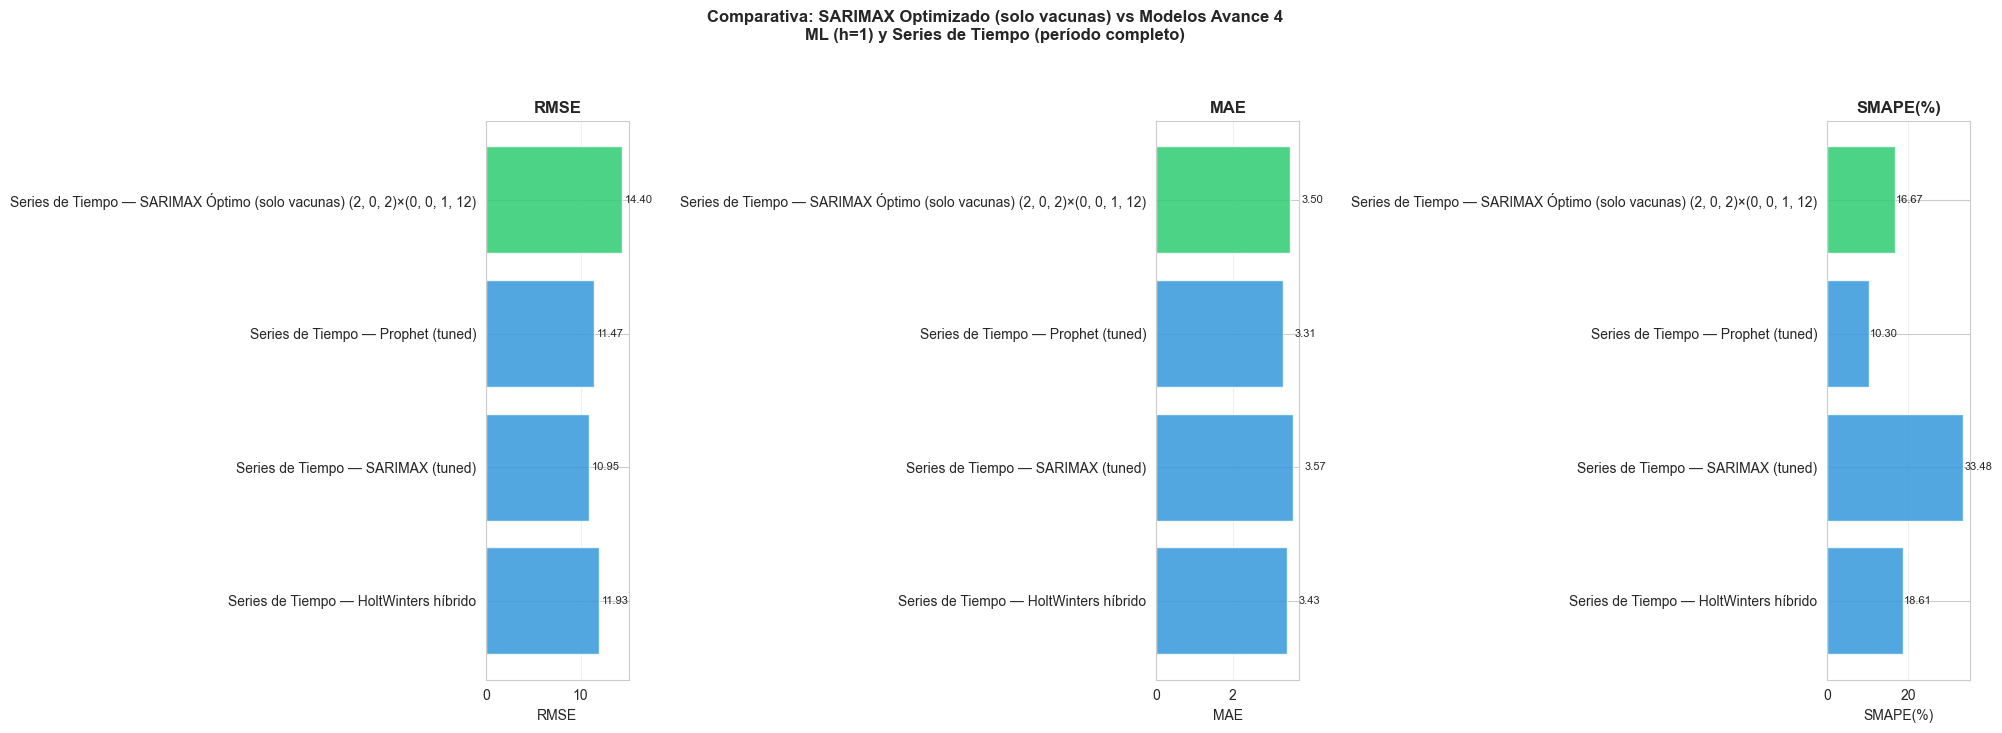

In [27]:
# ── Gráfica comparativa: SARIMAX optimizado vs todos los modelos del Avance 4 ──
# Filtrar solo modelos de Series de Tiempo y ML h=1 para comparación justa
df_comp_plot = df_comparativa[
    (df_comparativa["Horizonte"] == 1) | (df_comparativa["Horizonte"] == "Completo")
].copy()
df_comp_plot["Etiqueta"] = df_comp_plot["Enfoque"] + " — " + df_comp_plot["Modelo"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for i, metric in enumerate(["RMSE", "MAE", "SMAPE(%)"]):
    ax = axes[i]
    colors = []
    for _, row in df_comp_plot.iterrows():
        if "solo vacunas" in str(row["Modelo"]):
            colors.append("#2ecc71")  # Verde para el nuevo SARIMAX
        elif "Directo" in row["Enfoque"]:
            colors.append("#E74C3C")
        elif "Recursivo" in row["Enfoque"]:
            colors.append("#F39C12")
        else:
            colors.append("#3498DB")

    bars = ax.barh(df_comp_plot["Etiqueta"], df_comp_plot[metric], color=colors, alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric}", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    for bar, val in zip(bars, df_comp_plot[metric]):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            fontsize=8,
        )

plt.suptitle(
    "Comparativa: SARIMAX Optimizado (solo vacunas) vs Modelos Avance 4\n"
    "ML (h=1) y Series de Tiempo (período completo)",
    fontweight="bold",
    fontsize=12,
    y=1.04,
)
plt.tight_layout()
plt.show()

---
## 13. Conclusiones

### Proceso Realizado

1. **Estructura del DataFrame:** Se documentaron las variables del dataframe de modelación (`df_model`), resultado de la ingeniería de características previa, incluyendo la variable exógena de dosis de vacunación con desfase de 3 meses. Se excluyeron las columnas PCA y Factor Analysis por ser componentes estáticos no útiles para el pronóstico temporal.

2. **Análisis Exploratorio:** Se evaluó la estacionariedad de la serie mediante tests ADF y KPSS, y se inspeccionaron las funciones ACF/PACF para guiar la selección de órdenes del modelo.

3. **Selección de Hiperparámetros:** Se realizó una búsqueda exhaustiva sobre las combinaciones de órdenes no estacionales ($p, d, q$) y estacionales ($P, D, Q$, $s=12$), evaluando cada configuración con **TimeSeriesSplit** (5 folds, ventana de validación = 12 meses). Se aplicó:
   - **Filtro de calidad:** se descartaron modelos con coeficientes MA en la frontera ($|\theta| > 0.97$), indicativos de ajustes degenerados.
   - **Score compuesto:** promedio de rangos normalizados de RMSE, MAE y SMAPE, para equilibrar precisión y robustez (en lugar de solo RMSE).

4. **Evaluación:** Se comparó el modelo optimizado contra un baseline SARIMAX(1,1,1)(1,1,1,12) usando dos estrategias de pronóstico:
   - **Rolling 1-step-ahead** (métrica principal): avance mes a mes incorporando observaciones reales, sin re-estimar parámetros.
   - **Forecast directo multi-step** (referencia): predicción de los 60 meses de una sola vez.

5. **Diagnóstico:** Se analizaron los residuales del modelo óptimo para verificar supuestos de normalidad y ausencia de autocorrelación.

6. **Comparativa con Avance 4:** Se importaron los resultados del Avance 4 para contextualizar el desempeño del SARIMAX optimizado frente a todos los demás modelos evaluados previamente.

### Nota sobre la Variable Exógena

Siguiendo las indicaciones, se utilizó **únicamente la variable de dosis de vacunación con desfase** como variable exógena, a diferencia del Avance 4 que también incorporaba Isolation Forest Score y Bayesian Score.